In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [ ]:
default = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform = transforms.Compose([
    transforms.ColorJitter(brightness=0.15, hue=0.1),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

flip = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ColorJitter(brightness=0.15, hue=0.1),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


batch_size = 64

original = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

flipped = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=flip)

trainloader = torch.utils.data.DataLoader(torch.utils.data.ConcatDataset([original, flipped]), batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=default)

testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


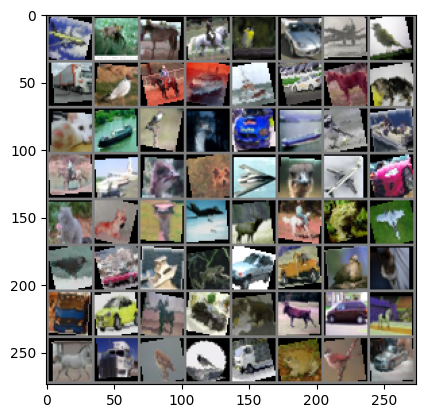

plane cat   horse horse bird  car   plane bird  truck bird  horse ship  ship  car   horse cat   cat   ship  bird  bird  car   ship  bird  ship  horse plane bird  dog   plane bird  plane car   cat   dog   bird  plane deer  horse cat   plane bird  car   ship  frog  car   truck bird  cat   truck car   horse car   dog   deer  car   horse horse truck bird  bird  truck frog  bird  car  


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3)
        self.conv1_bn = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, 3)
        self.conv2_bn = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, 3)
        self.conv3_bn = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256, 512, 3)
        self.conv4_bn = nn.BatchNorm2d(512)
        self.conv5 = nn.Conv2d(512, 1024, 3)
        self.conv5_bn = nn.BatchNorm2d(1024)
        self.conv6 = nn.Conv2d(1024, 2048, 3)
        self.conv6_bn = nn.BatchNorm2d(2048)
        self.dropout = nn.Dropout(p=0.2)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(2048 * 1 * 1, 768)
        self.fc1_bn = nn.BatchNorm1d(768)
        self.fc2 = nn.Linear(768, 160)
        self.fc2_bn = nn.BatchNorm1d(160)
        self.fc3 = nn.Linear(160, 10)

    def forward(self, x):
        x = F.gelu(self.conv1_bn(self.conv1(x)))
        x = F.gelu(self.conv2_bn(self.conv2(x)))
        x = self.pool(x)
        x = self.dropout(x)
        x = F.gelu(self.conv3_bn(self.conv3(x)))
        x = F.gelu(self.conv4_bn(self.conv4(x)))
        x = self.pool(x)
        x = self.dropout(x)
        x = F.gelu(self.conv5_bn(self.conv5(x)))
        x = F.gelu(self.conv6_bn(self.conv6(x)))
        x = self.dropout(x)
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.gelu(self.fc1_bn(self.fc1(x)))
        x = self.dropout(x)
        x = F.gelu(self.fc2_bn(self.fc2(x)))
        x = self.fc3(x)
        return x


net = Net()
net.to(device)

Net(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv1_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (conv2_bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
  (conv3_bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1))
  (conv4_bn): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1))
  (conv5_bn): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv6): Conv2d(1024, 2048, kernel_size=(3, 3), stride=(1, 1))
  (conv6_bn): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (p

In [ ]:
from torchsummary import summary
summary(net.cuda(), (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 30, 30]           1,792
       BatchNorm2d-2           [-1, 64, 30, 30]             128
            Conv2d-3          [-1, 128, 28, 28]          73,856
       BatchNorm2d-4          [-1, 128, 28, 28]             256
         MaxPool2d-5          [-1, 128, 14, 14]               0
           Dropout-6          [-1, 128, 14, 14]               0
            Conv2d-7          [-1, 256, 12, 12]         295,168
       BatchNorm2d-8          [-1, 256, 12, 12]             512
            Conv2d-9          [-1, 512, 10, 10]       1,180,160
      BatchNorm2d-10          [-1, 512, 10, 10]           1,024
        MaxPool2d-11            [-1, 512, 5, 5]               0
          Dropout-12            [-1, 512, 5, 5]               0
           Conv2d-13           [-1, 1024, 3, 3]       4,719,616
      BatchNorm2d-14           [-1, 102

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
#optimizer = optim.Adam(net.parameters(), lr=0.0003)
optimizer = optim.Adam(net.parameters())

In [ ]:
for epoch in range(150):  # loop over the dataset multiple times 14

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data[0].to(device), data[1].to(device)


        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 500 == 499:    # print every 500 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 500:.3f}')

            running_loss = 0.0


print('Finished Training')



[1,   500] loss: 1.510
[1,  1000] loss: 1.166
[1,  1500] loss: 1.014
[2,   500] loss: 0.895
[2,  1000] loss: 0.841
[2,  1500] loss: 0.797
[3,   500] loss: 0.728
[3,  1000] loss: 0.688
[3,  1500] loss: 0.667
[4,   500] loss: 0.633
[4,  1000] loss: 0.601
[4,  1500] loss: 0.589
[5,   500] loss: 0.544
[5,  1000] loss: 0.545
[5,  1500] loss: 0.531
[6,   500] loss: 0.493
[6,  1000] loss: 0.478
[6,  1500] loss: 0.466
[7,   500] loss: 0.422
[7,  1000] loss: 0.433
[7,  1500] loss: 0.427
[8,   500] loss: 0.392
[8,  1000] loss: 0.385
[8,  1500] loss: 0.384
[9,   500] loss: 0.343
[9,  1000] loss: 0.353
[9,  1500] loss: 0.357
[10,   500] loss: 0.310
[10,  1000] loss: 0.321
[10,  1500] loss: 0.316
[11,   500] loss: 0.272
[11,  1000] loss: 0.286
[11,  1500] loss: 0.294
[12,   500] loss: 0.258
[12,  1000] loss: 0.261
[12,  1500] loss: 0.270
[13,   500] loss: 0.228
[13,  1000] loss: 0.242
[13,  1500] loss: 0.236
[14,   500] loss: 0.209
[14,  1000] loss: 0.214
[14,  1500] loss: 0.224
[15,   500] loss: 0

In [ ]:
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

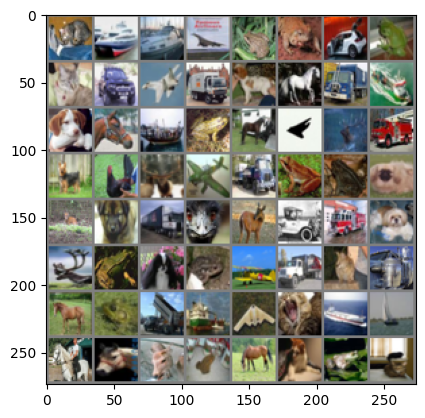

GroundTruth:  cat   ship  ship  plane


In [ ]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [ ]:
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

In [ ]:
outputs = net(images)

In [ ]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  cat   ship  ship  plane


In [ ]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct / total} %') #90.18

Accuracy of the network on the 10000 test images: 90.14 %


In [ ]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 91.0 %
Accuracy for class: car   is 94.7 %
Accuracy for class: bird  is 87.7 %
Accuracy for class: cat   is 80.4 %
Accuracy for class: deer  is 89.2 %
Accuracy for class: dog   is 86.9 %
Accuracy for class: frog  is 93.6 %
Accuracy for class: horse is 92.7 %
Accuracy for class: ship  is 94.4 %
Accuracy for class: truck is 94.9 %
